In [1]:
!pip install pandas yfinance matplotlib seaborn scikit-learn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1

In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [6]:
stock = yf.download("RELIANCE.NS",start="2022-01-01", end="2026-01-01")
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2022-01-03,1093.780640,1095.646251,1075.443709,1076.103491,5421611
2022-01-04,1118.465088,1119.784652,1093.848914,1099.263652,10847728
2022-01-05,1123.697632,1127.064782,1107.021470,1120.239614,11643813
2022-01-06,1099.536499,1116.599479,1096.123855,1115.325409,14447422
2022-01-07,1108.409180,1118.442148,1097.284117,1106.111377,13112115


In [8]:
stock.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 988 entries, 2022-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   988 non-null    float64
 1   (High, RELIANCE.NS)    988 non-null    float64
 2   (Low, RELIANCE.NS)     988 non-null    float64
 3   (Open, RELIANCE.NS)    988 non-null    float64
 4   (Volume, RELIANCE.NS)  988 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 46.3 KB


In [9]:
stock.describe()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,988.000000,988.000000,988.000000,988.000000,9.880000e+02
mean,1275.965837,1287.432713,1264.971554,1276.171222,1.292986e+07
std,149.139265,149.744177,148.630534,149.104152,6.644305e+06
min,1004.863220,1013.422547,991.926175,1006.259040,0.000000e+00
25%,1153.559723,1164.594249,1147.027971,1154.919356,8.724401e+06
50%,1241.256958,1253.969655,1230.361059,1239.611342,1.138326e+07
75%,1416.927521,1429.796511,1406.853012,1418.273472,1.546429e+07
max,1589.138062,1596.980044,1573.851280,1592.662006,8.199715e+07


In [10]:
stock['MA50'] = stock['Close'].rolling(window=50).mean()
stock['MA200'] = stock['Close'].rolling(window=200).mean()

stock[['Close','MA50','MA200']].tail()

Price,Close,MA50,MA200
Ticker,RELIANCE.NS,,
Date,,,
2025-12-24,1558.199951,1512.538005,1412.111169
2025-12-26,1559.199951,1516.204004,1414.052552
2025-12-29,1545.599976,1519.630002,1415.756611
2025-12-30,1539.800049,1522.460002,1417.231469
2025-12-31,1570.400024,1525.532002,1418.916101


In [11]:
stock['Daily Return'] = stock['Close'].pct_change()

volatility = stock['Daily Return'].std()
print("Volatility:", volatility)

Volatility: 0.013774303413976889


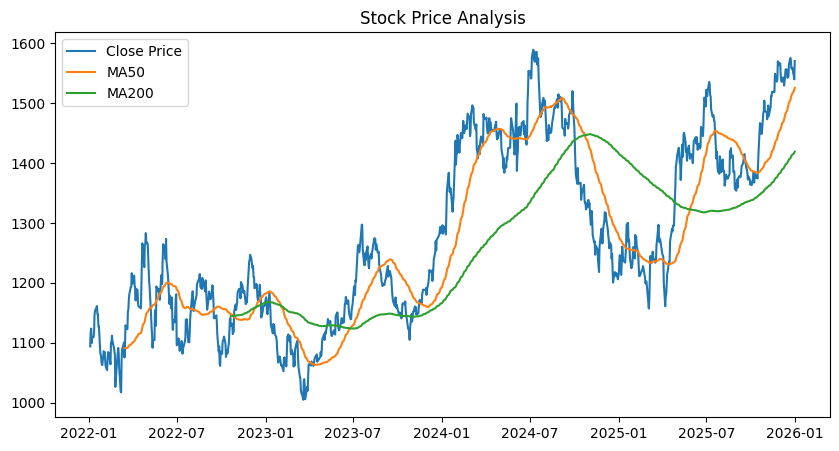

In [12]:
plt.figure(figsize=(10,5))

plt.plot(stock['Close'], label='Close Price')
plt.plot(stock['MA50'], label='MA50')
plt.plot(stock['MA200'],label='MA200')

plt.legend()
plt.title("Stock Price Analysis")
plt.show()

In [13]:
from sklearn.linear_model import LinearRegression
import numpy as np

stock['Prediction'] = stock['Close'].shift(-10)

X = np.array(stock[['Close']])[:-10]
y = np.array(stock['Prediction'])[:-10]

model = LinearRegression()
model.fit(X, y)

future = model.predict(np.array(stock[['Close']])[-10:])
print(future)

[1534.31101431 1534.31101431 1553.90211904 1563.6504191  1559.20211744
 1547.37171228 1548.31814469 1535.44668699 1529.95744832 1558.91825703]


In [14]:
stock.to_csv("stock_data.csv")